# WP5 — `wp5_05b` · Does exposure construction move the **decision**? The refit.

Plan §3.3, the half `wp5_05` could not run. `wp5_05` bounded the answer by perturbing the
**frozen predictions**; this notebook does the thing the plan actually registered — **refits the
model under each exposure build** and reads AUC, calibration, net benefit and the alert decision
off the refits.

**What makes it runnable now.** The §5.1 blocker was recorded as *"the design matrices are
absent."* They are not: `analysis/v12_referee_response/run/sl_matched_and_recal.py` carries
`design()`, `crossbasis()`, `climate_block()` and `fit_eval()`. What is absent is an **input** —
the frozen linked table. `data_quarantine/sl_ladder/sl_linked_v2equiv.csv` substitutes for it with
**measured** fidelity (label agreement 0.988, correlation 0.975 against the frozen panel), which is
what `wp4_02b` already ran on.

> **This is the independent-rebuild version of the registered re-run and must never be reported as
> the registered one.** Every contrast below is *within* the rebuild, so the rebuild's offset from
> the frozen run is common to all four arms and cannot manufacture an exposure effect.

---

In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from patsy import dmatrix, build_design_matrices
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

warnings.filterwarnings("ignore", category=FutureWarning)   # sklearn 1.9 deprecates penalty="l2";
                                                            # the frozen code passes it, so we keep it

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
DQ   = REPO / "data_quarantine"
LAD  = DQ / "sl_ladder"
W5   = DQ / "wp5_exposure"
FROZ = REPO / "ALT_STATS" / "frozen"
FIGS = REPO / "Manuscript_Figures" / "wp5"
FIGS.mkdir(parents=True, exist_ok=True)

# --- model constants, transcribed from sl_matched_and_recal.py via sl_04 / wp4_02b ---------
CLIMVARS = ["t2m_mean_c", "precip_sum_mm", "rh_mean_percent"]
LAGS  = list(range(0, 9))
CGRID = [0.1, 1.0, 10.0]
VDF   = LDF = 3
EPS   = 1e-6
clip  = lambda p: np.clip(p, EPS, 1 - EPS)
K     = ["geometry_id", "week_start"]

# --- decision constants, transcribed from wp5_05 ------------------------------------------
PSTAR  = 0.30
P_BAND = [0.10, 0.20, 0.30, 0.40]
N_BOOT = 2000
SEED   = json.loads((DQ / "m6_geomatics" / "nb00_provenance.json").read_text())["seed"]

print("seed          :", SEED)
print("threshold band:", P_BAND, " headline p* =", PSTAR)
print("C grid        :", CGRID, "(M5's)")

seed          : 20260612
threshold band: [0.1, 0.2, 0.3, 0.4]  headline p* = 0.3
C grid        : [0.1, 1.0, 10.0] (M5's)


---
## 1 · The inputs

Four tables. One supplies the **labels and the case history**; three supply the **exposure**.
Nothing else enters.

In [2]:
lk = pd.read_csv(LAD / "sl_linked_v2equiv.csv", parse_dates=["week_start", "week_end"])
tw = pd.read_csv(W5 / "wp5_temp_exposure_twin_srilanka_v1.csv",   parse_dates=["week_start"])
pw = pd.read_csv(W5 / "wp5_precip_exposure_twin_srilanka_v1.csv", parse_dates=["week_start"])
bc = pd.read_csv(W5 / "wp5_buildC_temp_exposure_srilanka_v1.csv", parse_dates=["week_start"])

for nm, d in [("linked (labels + cases)", lk), ("temp twin A'/B", tw),
              ("precip twin A'/B", pw), ("Build C temp", bc)]:
    print("%-26s %6d rows x %2d cols   %s -> %s" % (nm, len(d), d.shape[1],
          d.week_start.min().date(), d.week_start.max().date()))

linked (labels + cases)     10764 rows x 15 cols   2017-12-25 -> 2025-12-15
temp twin A'/B              10842 rows x 32 cols   2018-01-01 -> 2025-12-22
precip twin A'/B            10842 rows x 16 cols   2018-01-01 -> 2025-12-22
Build C temp                10842 rows x 37 cols   2018-01-01 -> 2025-12-22


### 1.1 · Gate — the linked table's exposure **is** Build A′

The rebuild (`sl_01`) and WP5 (`wp5_01`/`wp5_02`) built the area-weighted arm independently, from
the same staged CHIRPS/ERA5 windows but through different code. If they agree, Build A′ is the
baseline and every other arm is a swap against it. If they disagree, the whole ladder is
ungrounded. This is the cross-check that caught the mirrored-rainfall defect on 2026-08-18.

In [3]:
EXP = (tw[K + ["t2m_mean_c_a_frac", "t2m_mean_c_b_pop",
                "rh_mean_percent_a_frac", "rh_mean_percent_b_pop"]]
       .merge(pw[K + ["precip_sum_mm_a_frac", "precip_sum_mm_b_pop"]], on=K)
       .merge(bc[K + ["t2m_mean_c_c_frac", "t2m_mean_c_c_pop",
                      "rh_mean_percent_c_frac", "rh_mean_percent_c_pop"]], on=K))

chk = lk.merge(EXP, on=K, how="left")
AGREE = {}
for v, a in [("t2m_mean_c", "t2m_mean_c_a_frac"), ("precip_sum_mm", "precip_sum_mm_a_frac"),
             ("rh_mean_percent", "rh_mean_percent_a_frac")]:
    d = chk.dropna(subset=[v, a])
    AGREE[v] = float(np.abs(d[v] - d[a]).max())
    print("max |sl_01 %-16s - wp5 %-24s| = %.3e   (n=%d)" % (v, a, AGREE[v], len(d)))

unjoined = chk[EXP.columns.difference(K)].isna().any(axis=1)
print("\nlinked rows with no WP5 exposure : %d" % unjoined.sum())
print("  ...of which already flagged missing: %d" % int(chk.loc[unjoined, "exposure_missing_flag"].sum()))
assert max(AGREE.values()) < 1e-3, "the two independent builds of Build A' disagree"
assert int(chk.loc[unjoined, "exposure_missing_flag"].sum()) == int(unjoined.sum())
print("\nBuild A' agrees to <1e-3 in all three variables, and the swap can only touch rows")
print("that were already excluded. The baseline is grounded.")

max |sl_01 t2m_mean_c       - wp5 t2m_mean_c_a_frac       | = 1.801e-05   (n=10738)
max |sl_01 precip_sum_mm    - wp5 precip_sum_mm_a_frac    | = 4.167e-06   (n=10738)
max |sl_01 rh_mean_percent  - wp5 rh_mean_percent_a_frac  | = 3.197e-04   (n=10738)

linked rows with no WP5 exposure : 26
  ...of which already flagged missing: 26

Build A' agrees to <1e-3 in all three variables, and the swap can only touch rows
that were already excluded. The baseline is grounded.


---
## 2 · The four arms

The plan's ladder is A′ → B → C. Build C is *two* changes at once — the orography deficit **and**
sub-grid population placement — and the 2026-08-13 log is explicit that only the second is MAUP.
So the ladder is run with **four** arms, which separates them:

| arm | temperature / RH | rainfall | isolates |
|---|---|---|---|
| **A′** | `a_frac` | `a_frac` | baseline: fractional-area weights |
| **B** | `b_pop` | `b_pop` | **population weighting** — MAUP alone |
| **C_frac** | `c_frac` | `a_frac` | **orography deficit** alone |
| **C_pop** | `c_pop` | `b_pop` | the full ladder — both together |

Rainfall has no lapse correction, so it rides along with the weighting choice.

In [4]:
ARMS = {
    "A_frac": ("t2m_mean_c_a_frac", "precip_sum_mm_a_frac", "rh_mean_percent_a_frac"),
    "B_pop":  ("t2m_mean_c_b_pop",  "precip_sum_mm_b_pop",  "rh_mean_percent_b_pop"),
    "C_frac": ("t2m_mean_c_c_frac", "precip_sum_mm_a_frac", "rh_mean_percent_c_frac"),
    "C_pop":  ("t2m_mean_c_c_pop",  "precip_sum_mm_b_pop",  "rh_mean_percent_c_pop"),
}

def swap(arm):
    """Return the linked table with its three climate columns replaced by `arm`'s.

    Everything else - cases, population, epi_year/week, the missing flags - is untouched,
    so the labels and the split cannot move. Asserted in 3.1."""
    t, p, r = ARMS[arm]
    s = lk.drop(columns=CLIMVARS).merge(EXP[K + [t, p, r]], on=K, how="left")
    return s.rename(columns={t: "t2m_mean_c", p: "precip_sum_mm", r: "rh_mean_percent"})

print("how far each arm moves exposure from A' (district-weeks, the aggregation level to quote):")
ref = swap("A_frac")
for arm in ARMS:
    s = swap(arm)
    print("  %-7s  t2m %.4f C   precip %.4f mm   RH %.4f pp" % (arm,
          np.abs(s.t2m_mean_c - ref.t2m_mean_c).mean(),
          np.abs(s.precip_sum_mm - ref.precip_sum_mm).mean(),
          np.abs(s.rh_mean_percent - ref.rh_mean_percent).mean()))
sb, sc = swap("B_pop"), swap("C_pop")
print("  %-7s  t2m %.4f C   precip %.4f mm   RH %.4f pp   <- measured B->C, not from A'"
      % ("B->C", np.abs(sc.t2m_mean_c - sb.t2m_mean_c).mean(),
         np.abs(sc.precip_sum_mm - sb.precip_sum_mm).mean(),
         np.abs(sc.rh_mean_percent - sb.rh_mean_percent).mean()))
print("\nwp5_03/wp5_04 on file: |A'->B| t2m 0.205 C, precip 3.40 mm; |B->C| t2m 0.306 C;")
print("orography deficit alone 0.223 C. All three reproduce, so the ladder is the frozen one.")

how far each arm moves exposure from A' (district-weeks, the aggregation level to quote):
  A_frac   t2m 0.0000 C   precip 0.0000 mm   RH 0.0000 pp
  B_pop    t2m 0.2053 C   precip 3.4011 mm   RH 0.7709 pp
  C_frac   t2m 0.2232 C   precip 0.0000 mm   RH 0.7018 pp
  C_pop    t2m 0.4255 C   precip 3.4011 mm   RH 1.5411 pp
  B->C     t2m 0.3060 C   precip 0.0000 mm   RH 1.0321 pp   <- measured B->C, not from A'

wp5_03/wp5_04 on file: |A'->B| t2m 0.205 C, precip 3.40 mm; |B->C| t2m 0.306 C;
orography deficit alone 0.223 C. All three reproduce, so the ladder is the frozen one.


---
## 3 · The frame

Transcribed from `sl_matched_and_recal.py` (via `sl_04` and `wp4_02b`), unchanged, and wrapped in a
function only so it can be run four times. The 28-day-ahead label, the district-specific 75th
percentile, the 2022/2023 split, the AR lags, the 0–8 week climate lags, the harmonics, the district
dummies, and the train-mean imputation are all the frozen pipeline's.

In [5]:
AR   = ["inc_t", "inc_lag1", "inc_lag2", "inc_lag4"]
SEAS = ["sin1", "cos1", "sin2", "cos2"]

def build_frame(m):
    f = m[(m.outcome_missing_flag == 0) & (m.exposure_missing_flag == 0) & (m.population_missing_flag == 0)
          & (m.epi_year >= 2018) & (m.epi_year <= 2025)].copy().sort_values(K).reset_index(drop=True)

    fut = f[K + ["dengue_incidence_per_100k"]].rename(columns={"dengue_incidence_per_100k": "inc_future"})
    fut["week_start"] = fut["week_start"] - pd.Timedelta(days=28)
    f = f.merge(fut, on=K, how="left"); f = f[f.inc_future.notna()].copy()

    f["split"] = np.where(f.week_start.dt.year <= 2022, "train", "test")
    g = f[f.split == "train"].groupby("geometry_id")["dengue_incidence_per_100k"]
    f = f.merge(g.quantile(0.75, interpolation="higher").rename("thr75").reset_index(),
                on="geometry_id", how="left")
    f["y"] = (f["inc_future"] > f["thr75"]).astype(int)

    for L in [1, 2, 4]:
        t = f[K + ["dengue_incidence_per_100k"]].rename(columns={"dengue_incidence_per_100k": f"inc_lag{L}"}).copy()
        t["week_start"] = t["week_start"] + pd.Timedelta(days=7 * L); f = f.merge(t, on=K, how="left")
    f["inc_t"] = f["dengue_incidence_per_100k"]
    for v in CLIMVARS:
        for L in LAGS:
            t = f[K + [v]].rename(columns={v: f"{v}__L{L}"}).copy()
            t["week_start"] = t["week_start"] + pd.Timedelta(days=7 * L); f = f.merge(t, on=K, how="left")

    w = 2 * np.pi * f["epi_week"] / 52.18
    f["sin1"], f["cos1"], f["sin2"], f["cos2"] = np.sin(w), np.cos(w), np.sin(2 * w), np.cos(2 * w)
    rd = pd.get_dummies(f["geometry_id"], prefix="rd", drop_first=True).astype(float)
    f = pd.concat([f, rd], axis=1); RD = list(rd.columns)

    LAGCOLS = ["inc_lag1", "inc_lag2", "inc_lag4"] + [f"{v}__L{L}" for v in CLIMVARS for L in LAGS]
    tr0 = f[f.split == "train"]
    for c in LAGCOLS:
        f[c] = f[c].fillna(tr0[c].mean())
    return f, RD

f0, RD0 = build_frame(lk)
print("rows %d | train %d | test %d | districts %d" % (
      len(f0), (f0.split == "train").sum(), (f0.split == "test").sum(), f0.geometry_id.nunique()))
print("test prevalence %.4f   (frozen panel: 3926 rows, 0.3365)" % f0.loc[f0.split == "test", "y"].mean())

rows 10490 | train 6564 | test 3926 | districts 26
test prevalence 0.3372   (frozen panel: 3926 rows, 0.3365)


### 3.1 · Gate — the panel must not depend on the exposure

The label is built from **case counts**, and the split from the calendar. Neither reads a climate
column, so all four arms must produce a byte-identical panel: same rows, same `y`, same `thr75`,
same split. If they do not, the contrast is comparing different questions and everything downstream
is void.

In [6]:
FR = {arm: build_frame(swap(arm)) for arm in ARMS}
PANEL = ["geometry_id", "week_start", "y", "split", "thr75"]
base = FR["A_frac"][0][PANEL].reset_index(drop=True)
same = {arm: base.equals(FR[arm][0][PANEL].reset_index(drop=True)) for arm in ARMS}
for arm, v in same.items():
    print("%-8s panel identical to A' : %s" % (arm, v))
assert all(same.values()), "the exposure swap moved the labels or the split"

f, RD  = FR["A_frac"]
TRAIN  = (f.split == "train").values
TEST   = (f.split == "test").values
YTE    = f.loc[TEST, "y"].values
te_unit = f.loc[TEST, "geometry_id"].values
UNITS  = sorted(pd.unique(te_unit))
IDX    = {u: np.flatnonzero(te_unit == u) for u in UNITS}
print("\nshared panel: %d rows, %d test rows, %d districts, %d events" % (
      len(base), TEST.sum(), len(UNITS), YTE.sum()))

A_frac   panel identical to A' : True
B_pop    panel identical to A' : True
C_frac   panel identical to A' : True
C_pop    panel identical to A' : True

shared panel: 10490 rows, 3926 test rows, 26 districts, 1324 events


---
## 4 · The design and the fitter

Also transcribed. The only structural point worth pausing on: **the spline knots are re-derived
from each arm's own training distribution.** That is what "re-run the pipeline under this build"
means — the pipeline places its knots by looking at its data. A fixed-knot variant is measured in
§9 so the reader can see how much of any movement is knot placement rather than exposure.

In [7]:
def make_design(f, RD, TRAIN):
    """Return this arm's design() closure. Knots come from THIS arm's training rows."""
    DIs = {v: dmatrix(f"cr(x, df={VDF}) - 1", {"x": f.loc[TRAIN, f"{v}__L0"].values},
                      return_type="dataframe").design_info for v in CLIMVARS}
    BLAG = np.asarray(dmatrix(f"cr(x, df={LDF}) - 1", {"x": np.array(LAGS, float)}, return_type="dataframe"))

    def crossbasis(rows, v):
        n = len(rows); Vb = np.empty((n, len(LAGS), VDF))
        for i, L in enumerate(LAGS):
            Vb[:, i, :] = np.asarray(build_design_matrices([DIs[v]], {"x": rows[f"{v}__L{L}"].values})[0])
        return np.einsum("nlj,lk->njk", Vb, BLAG).reshape(n, VDF * LDF)

    def climate_block(rows): return np.concatenate([crossbasis(rows, v) for v in CLIMVARS], axis=1)

    def design(rows, kind):
        if kind == "M5":      return np.concatenate([rows[AR].values, climate_block(rows), rows[SEAS + RD].values], axis=1)
        if kind == "M4":      return np.concatenate([rows[AR].values, climate_block(rows)], axis=1)
        if kind == "matched": return np.concatenate([rows[AR].values, rows[SEAS + RD].values], axis=1)
        raise ValueError(kind)
    return design, DIs

DES = {arm: make_design(FR[arm][0], FR[arm][1], (FR[arm][0].split == "train").values)[0] for arm in ARMS}
d0 = DES["A_frac"]
print("M5      width:", d0(f.head(5), "M5").shape[1],  "= 4 AR + 27 climate + 4 season +", len(RD), "district dummies")
print("M4      width:", d0(f.head(5), "M4").shape[1],  "= 4 AR + 27 climate           (no season, NO district FE)")
print("matched width:", d0(f.head(5), "matched").shape[1], "= M5 with the climate block deleted")

M5      width: 60 = 4 AR + 27 climate + 4 season + 25 district dummies
M4      width: 31 = 4 AR + 27 climate           (no season, NO district FE)
matched width: 33 = M5 with the climate block deleted


In [8]:
def time_blocks(rows):
    yrs = sorted(rows["epi_year"].unique()); folds = []
    for i in range(1, len(yrs)):
        tri = rows.index[rows["epi_year"] <= yrs[i - 1]]; vai = rows.index[rows["epi_year"] == yrs[i]]
        if len(vai) and rows.loc[tri, "y"].nunique() > 1 and rows.loc[vai, "y"].nunique() > 1:
            folds.append((tri, vai))
    return folds

def fit_eval(f, design, kind):
    """Body transcribed from sl_04 fit_eval: expanding-year C selection on the train split,
    refit at the winner, the |coef|>15 fallback, then predict the test split."""
    TR = (f.split == "train").values; TE = (f.split == "test").values
    rtr, rpr = f.loc[TR], f.loc[TE]
    Xtr_full, Xpr = design(rtr, kind), design(rpr, kind)
    mu, sd = Xtr_full.mean(0), Xtr_full.std(0); sd[sd == 0] = 1
    ytr = rtr["y"].values

    bestC, bestS = None, -1
    for C in CGRID:
        sc = []
        for tri, vai in time_blocks(rtr):
            Xt = (design(rtr.loc[tri], kind) - mu) / sd; Xv = (design(rtr.loc[vai], kind) - mu) / sd
            clf = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=8000).fit(Xt, rtr.loc[tri, "y"].values)
            sc.append(roc_auc_score(rtr.loc[vai, "y"].values, clf.predict_proba(Xv)[:, 1]))
        if np.mean(sc) > bestS: bestS, bestC = float(np.mean(sc)), C

    clf = LogisticRegression(penalty="l2", C=bestC, solver="lbfgs", max_iter=8000).fit((Xtr_full - mu) / sd, ytr)
    if np.abs(clf.coef_).max() > 15:
        clf = LogisticRegression(penalty="l2", C=0.1, solver="lbfgs", max_iter=8000).fit((Xtr_full - mu) / sd, ytr)
    return clip(clf.predict_proba((Xpr - mu) / sd)[:, 1]), bestC

# --- metrics, transcribed from sl_matched_and_recal.py / wp4_02b --------------------------
def auc(y, p):
    r = pd.Series(p).rank().values; n1 = int(y.sum()); n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def nb_stat(y, p, ps=PSTAR):
    a = p >= ps; n = len(y)
    return (a & (y == 1)).sum() / n - (a & (y == 0)).sum() / n * (ps / (1 - ps))

def cal_is(y, p):
    lp = np.log(clip(p) / (1 - clip(p)))
    r  = sm.GLM(y, sm.add_constant(lp), family=sm.families.Binomial()).fit()
    r0 = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Binomial(), offset=lp).fit()
    return float(r0.params[0]), float(r.params[1])

def cal_slope(y, p): return cal_is(y, p)[1]

print("fitter ready | test rows", int(TEST.sum()))

fitter ready | test rows 3926


---
## 5 · Gate 1 — the baseline reproduces `sl_04` exactly

Before any arm is compared to any other, the fitter has to be shown to be the frozen one. Fit M5
and its no-climate twin on the linked table's **own** columns and check against the predictions
`sl_04` wrote. Not "close" — `wp4_02b` established that this environment reproduces them to
**exactly 0.0**, so anything else means something has drifted.

In [9]:
z = np.load(LAD / "sl_predictions.npz")
p_lk_M5, C_lk = fit_eval(f0, make_design(f0, RD0, (f0.split == "train").values)[0], "M5")
p_lk_nc, _    = fit_eval(f0, make_design(f0, RD0, (f0.split == "train").values)[0], "matched")

g_M5 = float(np.abs(p_lk_M5 - z["M5"]).max())
g_nc = float(np.abs(p_lk_nc - z["M5_noclim"]).max())
print("max |refit - sl_04 M5|        = %.3e   (C=%s)" % (g_M5, C_lk))
print("max |refit - sl_04 M5_noclim| = %.3e" % g_nc)
assert g_M5 == 0.0 and g_nc == 0.0, "the fitter is not sl_04's"
print("\nExact. The pipeline below is the frozen one; only the exposure column changes.")

max |refit - sl_04 M5|        = 0.000e+00   (C=10.0)
max |refit - sl_04 M5_noclim| = 0.000e+00

Exact. The pipeline below is the frozen one; only the exposure column changes.


---
## 6 · Fit every arm

Three models × four arms. `M5` is the model the paper reports. `M4` is the same climate block with
**no district fixed effects and no harmonics** — it is here to test a structural claim in §9.
`matched` is M5 with the climate block deleted; it cannot see the exposure at all, so it is the
**negative control**: if it moves under any arm, the swap has leaked somewhere it should not.

In [10]:
t0 = time.time()
P, CSEL = {}, {}
for arm in ARMS:
    fa = FR[arm][0]
    for kind in ["M5", "M4", "matched"]:
        P[(arm, kind)], CSEL[(arm, kind)] = fit_eval(fa, DES[arm], kind)
    print("%-8s fitted  (C: M5=%-5s M4=%-5s matched=%-5s)  %4.1fs" % (
          arm, CSEL[(arm, "M5")], CSEL[(arm, "M4")], CSEL[(arm, "matched")], time.time() - t0))

A_frac   fitted  (C: M5=10.0  M4=1.0   matched=10.0 )   0.9s


B_pop    fitted  (C: M5=10.0  M4=1.0   matched=10.0 )   1.7s


C_frac   fitted  (C: M5=10.0  M4=0.1   matched=10.0 )   2.6s


C_pop    fitted  (C: M5=10.0  M4=1.0   matched=10.0 )   3.5s


### 6.1 · Gate 2 — the negative control, and the cost of the swap path itself

Two nulls that have to hold before any number is read.

**The negative control.** `matched` has no climate block. It must be bit-identical across all four
arms. This is the 2026-08-18 diagnostic applied *before* the fact rather than after: *if a data
change is real, the models that cannot see the data must not move.*

**The swap-path null.** Arm A′ is rebuilt through the merge-and-rename path from WP5's own
`a_frac` columns, while the §5 baseline came from the linked table's columns directly. They are the
same numbers to CSV precision, so the difference between them is the **noise floor** — the movement
the machinery produces on its own. Every flip count below has to be read against it.

In [11]:
for arm in ARMS:
    d = float(np.abs(P[(arm, "matched")] - P[("A_frac", "matched")]).max())
    print("negative control  %-8s  max|dp| vs A' = %.3e" % (arm, d))
NC_MAX = max(float(np.abs(P[(a, "matched")] - P[("A_frac", "matched")]).max()) for a in ARMS)
assert NC_MAX == 0.0, "a model with no climate block moved when the climate changed"

FLOOR_DP = float(np.abs(P[("A_frac", "M5")] - p_lk_M5).max())
FLOOR = {ps: int(((P[("A_frac", "M5")] >= ps) != (p_lk_M5 >= ps)).sum()) for ps in P_BAND}
print("\nswap-path null (A' via the swap vs A' from the linked table):")
print("  max|dp| %.2e | dAUC %+.5f | dNB@%.2f %+.5f" % (
      FLOOR_DP, auc(YTE, P[("A_frac", "M5")]) - auc(YTE, p_lk_M5),
      PSTAR, nb_stat(YTE, P[("A_frac", "M5")]) - nb_stat(YTE, p_lk_M5)))
print("  flips: " + "  ".join("p*=%.2f: %d" % (ps, FLOOR[ps]) for ps in P_BAND))
print("\nThat is the noise floor. Read every flip count in section 8 against it.")

negative control  A_frac    max|dp| vs A' = 0.000e+00
negative control  B_pop     max|dp| vs A' = 0.000e+00
negative control  C_frac    max|dp| vs A' = 0.000e+00
negative control  C_pop     max|dp| vs A' = 0.000e+00

swap-path null (A' via the swap vs A' from the linked table):
  max|dp| 1.06e-03 | dAUC +0.00008 | dNB@0.30 -0.00025
  flips: p*=0.10: 1  p*=0.20: 0  p*=0.30: 3  p*=0.40: 1

That is the noise floor. Read every flip count in section 8 against it.


---
## 7 · What each build is worth

AUC, calibration-in-the-large, calibration slope, Brier and net benefit at the headline threshold,
for every arm and model. Levels first; the contrasts are section 8.

In [12]:
rows = []
for arm in ARMS:
    for kind in ["M5", "M4", "matched"]:
        p = P[(arm, kind)]; citl, slope = cal_is(YTE, p)
        rows.append({"arm": arm, "model": kind, "C": CSEL[(arm, kind)],
                     "AUC": auc(YTE, p), "CITL": citl, "cal_slope": slope,
                     "Brier": brier_score_loss(YTE, p), "NB@0.30": nb_stat(YTE, p),
                     "alerts": int((p >= PSTAR).sum())})
MET = pd.DataFrame(rows)
print(MET.round(4).to_string(index=False))
print("\nThe no-climate row is identical four times over, as it must be.")

   arm   model    C    AUC   CITL  cal_slope  Brier  NB@0.30  alerts
A_frac      M5 10.0 0.7653 0.5485     1.0847 0.1870   0.1386    1247
A_frac      M4  1.0 0.7604 0.5300     1.1938 0.1913   0.1290    1205
A_frac matched 10.0 0.7323 0.5900     1.1559 0.1994   0.1223    1060
 B_pop      M5 10.0 0.7668 0.5498     1.1081 0.1870   0.1399    1245
 B_pop      M4  1.0 0.7634 0.5234     1.1967 0.1904   0.1279    1212
 B_pop matched 10.0 0.7323 0.5900     1.1559 0.1994   0.1223    1060
C_frac      M5 10.0 0.7659 0.5789     1.1083 0.1881   0.1361    1213
C_frac      M4  0.1 0.7550 0.5079     1.1849 0.1921   0.1247    1211
C_frac matched 10.0 0.7323 0.5900     1.1559 0.1994   0.1223    1060
 C_pop      M5 10.0 0.7650 0.5711     1.1192 0.1883   0.1390    1210
 C_pop      M4  1.0 0.7586 0.5053     1.1743 0.1907   0.1286    1229
 C_pop matched 10.0 0.7323 0.5900     1.1559 0.1994   0.1223    1060

The no-climate row is identical four times over, as it must be.


In [13]:
NBB = []
for arm in ARMS:
    for kind in ["M5", "M4"]:
        for ps in P_BAND:
            NBB.append({"arm": arm, "model": kind, "p_star": ps,
                        "NB": nb_stat(YTE, P[(arm, kind)], ps),
                        "alerts": int((P[(arm, kind)] >= ps).sum())})
NBB = pd.DataFrame(NBB)
print("NET BENEFIT ACROSS THE THRESHOLD BAND (M5)\n")
print(NBB[NBB.model == "M5"].pivot(index="arm", columns="p_star", values="NB").round(4).to_string())

NET BENEFIT ACROSS THE THRESHOLD BAND (M5)

p_star     0.1     0.2     0.3     0.4
arm                                   
A_frac  0.2595  0.1915  0.1386  0.0985
B_pop   0.2607  0.1898  0.1399  0.0993
C_frac  0.2574  0.1911  0.1361  0.0993
C_pop   0.2589  0.1872  0.1390  0.0987


---
## 8 · The contrasts, and the decision

Two different questions, and they do not have the same answer.

**Does the build change the model's *performance*?** — ΔAUC, ΔNB, Δslope against Build A′, each
with a **paired** RDHS-cluster bootstrap: resample districts once, recompute both arms on the same
resample, take the difference. Paired, because the arms share every row.

**Does the build change the *decision*?** — for how many district-weeks does `p ≥ p*` change sign?
Net benefit is a *pooled average* and can sit still while individual alerts move; the flip count is
the only statistic here that sees them.

In [14]:
def boot_delta(pa, pb, stat, B=N_BOOT, seed=SEED):
    r = np.random.default_rng(seed); out = np.empty(B)
    for k in range(B):
        pick = np.concatenate([IDX[u] for u in r.choice(UNITS, len(UNITS), replace=True)])
        yb = YTE[pick]
        if yb.sum() in (0, len(yb)): out[k] = np.nan; continue
        out[k] = stat(yb, pa[pick]) - stat(yb, pb[pick])
    out = out[np.isfinite(out)]
    return float(np.mean(out)), float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

t0 = time.time(); rows = []
for kind in ["M5", "M4"]:
    for arm in ["B_pop", "C_frac", "C_pop"]:
        for sname, stat in [("dAUC", auc), ("dNB@0.30", nb_stat), ("dCalSlope", cal_slope)]:
            m, lo, hi = boot_delta(P[(arm, kind)], P[("A_frac", kind)], stat)
            rows.append({"model": kind, "arm": arm, "stat": sname,
                         "point": stat(YTE, P[(arm, kind)]) - stat(YTE, P[("A_frac", kind)]),
                         "boot_mean": m, "lo": lo, "hi": hi, "excludes_0": bool((lo > 0) == (hi > 0))})
BOOT = pd.DataFrame(rows)
print("DELTAS vs Build A'  (paired RDHS-cluster bootstrap, B=%d, seed=%d)   %.0fs\n" % (N_BOOT, SEED, time.time() - t0))
print(BOOT.round(4).to_string(index=False))

DELTAS vs Build A'  (paired RDHS-cluster bootstrap, B=2000, seed=20260612)   61s

model    arm      stat   point  boot_mean      lo     hi  excludes_0
   M5  B_pop      dAUC  0.0015     0.0014 -0.0008 0.0037       False
   M5  B_pop  dNB@0.30  0.0013     0.0013 -0.0015 0.0043       False
   M5  B_pop dCalSlope  0.0234     0.0231  0.0052 0.0424        True
   M5 C_frac      dAUC  0.0005     0.0006 -0.0018 0.0028       False
   M5 C_frac  dNB@0.30 -0.0025    -0.0025 -0.0063 0.0009       False
   M5 C_frac dCalSlope  0.0235     0.0240  0.0097 0.0374        True
   M5  C_pop      dAUC -0.0003    -0.0003 -0.0040 0.0036       False
   M5  C_pop  dNB@0.30  0.0004     0.0004 -0.0022 0.0031       False
   M5  C_pop dCalSlope  0.0345     0.0350  0.0101 0.0618        True
   M4  B_pop      dAUC  0.0029     0.0029 -0.0018 0.0079       False
   M4  B_pop  dNB@0.30 -0.0011    -0.0011 -0.0054 0.0037       False
   M4  B_pop dCalSlope  0.0029     0.0032 -0.0290 0.0385       False
   M4 C_frac      dAU

In [15]:
rows = []
for kind in ["M5", "M4"]:
    for arm in ["B_pop", "C_frac", "C_pop"]:
        for ps in P_BAND:
            a = P[("A_frac", kind)] >= ps; b = P[(arm, kind)] >= ps
            rows.append({"model": kind, "arm": arm, "p_star": ps,
                         "flips": int((a != b).sum()), "flip_pct": 100 * float((a != b).mean()),
                         "off_to_on": int(((~a) & b).sum()), "on_to_off": int((a & (~b)).sum()),
                         "noise_floor": FLOOR[ps]})
FLIP = pd.DataFrame(rows)
print("DECISION FLIPS vs Build A'  (n = %d test district-weeks)\n" % len(YTE))
print(FLIP.round(2).to_string(index=False))

DECISION FLIPS vs Build A'  (n = 3926 test district-weeks)

model    arm  p_star  flips  flip_pct  off_to_on  on_to_off  noise_floor
   M5  B_pop     0.1     90      2.29         53         37            1
   M5  B_pop     0.2     73      1.86         38         35            0
   M5  B_pop     0.3     72      1.83         35         37            3
   M5  B_pop     0.4     60      1.53         25         35            1
   M5 C_frac     0.1     71      1.81         27         44            1
   M5 C_frac     0.2     64      1.63         18         46            0
   M5 C_frac     0.3     64      1.63         15         49            3
   M5 C_frac     0.4     67      1.71         15         52            1
   M5  C_pop     0.1    135      3.44         77         58            1
   M5  C_pop     0.2    122      3.11         55         67            0
   M5  C_pop     0.3    121      3.08         42         79            3
   M5  C_pop     0.4     93      2.37         21         72     

### 8.1 · Read the two together

Net benefit moves by fractions of a thousandth and never leaves zero, while a hundred-odd alerts
change sign. This is the **fourth** independent appearance in this study of the same property:
**ΔNB is blind to threshold-local perturbations.** It is an average over the whole test panel of a
quantity in which a false positive and a true positive partly cancel, so alerts that flip in
opposite directions net out. It is the right *decision-theoretic summary* and the wrong
*sensitivity statistic*. Report both, and never let ΔNB alone answer "does the build matter?".

In [16]:
print("at p* = %.2f, M5:\n" % PSTAR)
for arm in ["B_pop", "C_frac", "C_pop"]:
    r = FLIP[(FLIP.model == "M5") & (FLIP.arm == arm) & (FLIP.p_star == PSTAR)].iloc[0]
    b = BOOT[(BOOT.model == "M5") & (BOOT.arm == arm) & (BOOT.stat == "dNB@0.30")].iloc[0]
    print("  %-7s  %3d alerts flip (%.2f%%, floor %d; %d on, %d off)   yet dNB = %+.4f [%+.4f, %+.4f]"
          % (arm, r.flips, r.flip_pct, r.noise_floor, r.off_to_on, r.on_to_off, b.point, b.lo, b.hi))
print("\nB_pop's flips are near-symmetric; the Build C arms are not. Section 10 says why.")

at p* = 0.30, M5:

  B_pop     72 alerts flip (1.83%, floor 3; 35 on, 37 off)   yet dNB = +0.0013 [-0.0015, +0.0043]
  C_frac    64 alerts flip (1.63%, floor 3; 15 on, 49 off)   yet dNB = -0.0025 [-0.0063, +0.0009]
  C_pop    121 alerts flip (3.08%, floor 3; 42 on, 79 off)   yet dNB = +0.0004 [-0.0022, +0.0031]

B_pop's flips are near-symmetric; the Build C arms are not. Section 10 says why.


---
## 9 · Against `wp5_05`'s envelope — was the bound any good?

`wp5_05` could not refit, so it **bounded** the answer: it perturbed the frozen predictions by a
transfer coefficient estimated on contemporaneous exposure, and warned in its own provenance that
this is *"attenuated by the missing lag structure"* — i.e. it should under-count. That is a
prediction with a direction, and this notebook is the first thing able to test it.

In [17]:
ENV = pd.read_csv(W5 / "wp5_decision_flip_summary_srilanka_v1.csv")
env = ENV[(ENV.p_star == PSTAR) & (ENV.spec == "+ district FE + harm")].set_index("rung")
cmp_rows = []
for rung, arm in [("A'->B", "B_pop"), ("A'->C", "C_pop")]:
    r = FLIP[(FLIP.model == "M5") & (FLIP.arm == arm) & (FLIP.p_star == PSTAR)].iloc[0]
    e = env.loc[rung]
    cmp_rows.append({"rung": rung, "envelope_flips": int(e.flips_raw), "envelope_pct": float(e.flip_pct_raw),
                     "refit_flips": int(r.flips), "refit_pct": float(r.flip_pct),
                     "refit_minus_envelope": int(r.flips) - int(e.flips_raw),
                     "envelope_dNB": float(e.dNB_raw),
                     "refit_dNB": float(BOOT[(BOOT.model == "M5") & (BOOT.arm == arm) & (BOOT.stat == "dNB@0.30")].point.iloc[0])})
CMP = pd.DataFrame(cmp_rows)
print("ENVELOPE (wp5_05, no refit)  vs  REFIT (this notebook), M5, p* = %.2f\n" % PSTAR)
print(CMP.round(4).to_string(index=False))
print("\nwp5_05's headline bound on the flip rate was 6.0% raw / 6.4% recalibrated.")
print("The largest refit flip rate anywhere in the band is %.2f%%." % FLIP[FLIP.model == "M5"].flip_pct.max())

ENVELOPE (wp5_05, no refit)  vs  REFIT (this notebook), M5, p* = 0.30

 rung  envelope_flips  envelope_pct  refit_flips  refit_pct  refit_minus_envelope  envelope_dNB  refit_dNB
A'->B              76        1.9358           72     1.8339                    -4       -0.0012     0.0013
A'->C             104        2.6490          121     3.0820                    17       -0.0009     0.0004

wp5_05's headline bound on the flip rate was 6.0% raw / 6.4% recalibrated.
The largest refit flip rate anywhere in the band is 3.44%.


**The envelope held, and its stated bias had the stated sign.** It bracketed the truth at both
rungs and its 6.0% bound was never approached. On A′→B it was within a few alerts; on A′→C it
under-counted, which is exactly what an estimator built on contemporaneous exposure should do
against a model that reads eight weeks of lags. **A bound whose error direction is known in advance
is worth building even when the refit is coming** — and this one earned its place in the record
rather than being superseded by it.

### 9.1 · Is any of this just the knots moving?

Each arm re-derived its spline knots from its own training distribution. Refit every arm with the
knots **frozen at Build A′'s** and see whether the flip counts survive. If they collapse, the result
is an artifact of knot placement; if they hold, the exposure is doing the work.

In [18]:
des_fixed = make_design(FR["A_frac"][0], FR["A_frac"][1], (FR["A_frac"][0].split == "train").values)[0]
PFX = {arm: fit_eval(FR[arm][0], des_fixed, "M5")[0] for arm in ARMS}
rows = []
for arm in ["B_pop", "C_frac", "C_pop"]:
    fl_free  = int(((P[("A_frac", "M5")] >= PSTAR) != (P[(arm, "M5")] >= PSTAR)).sum())
    fl_fixed = int(((PFX["A_frac"] >= PSTAR) != (PFX[arm] >= PSTAR)).sum())
    rows.append({"arm": arm, "flips_knots_per_arm": fl_free, "flips_knots_fixed_at_A": fl_fixed,
                 "dAUC_free": auc(YTE, P[(arm, "M5")]) - auc(YTE, P[("A_frac", "M5")]),
                 "dAUC_fixed": auc(YTE, PFX[arm]) - auc(YTE, PFX["A_frac"])})
KNOT = pd.DataFrame(rows)
print("KNOT SENSITIVITY (M5, p* = %.2f)\n" % PSTAR)
print(KNOT.round(4).to_string(index=False))

KNOT SENSITIVITY (M5, p* = 0.30)

   arm  flips_knots_per_arm  flips_knots_fixed_at_A  dAUC_free  dAUC_fixed
 B_pop                   72                      74     0.0015      0.0014
C_frac                   64                      65     0.0005      0.0002
 C_pop                  121                     119    -0.0003     -0.0001


---
## 10 · Why does Build C move M5 at all?

The 2026-08-13 decision log records a structural argument: Build C differs from Build B by a
**constant per-district offset**, so *"district-relative models absorb it exactly → Build C cannot
flip any alert."* M5 carries district fixed effects. It flips alerts anyway. Rather than argue
about it, measure it — first confirm the premise, then break the model in the one place the
argument depends on.

In [19]:
fb = FR["B_pop"][0]; fc = FR["C_pop"][0]
o_t = pd.DataFrame({"g": fb.geometry_id.values, "d": (fc.t2m_mean_c - fb.t2m_mean_c).values}).groupby("g")["d"]
o_r = pd.DataFrame({"g": fb.geometry_id.values, "d": (fc.rh_mean_percent - fb.rh_mean_percent).values}).groupby("g")["d"]
print("B->C t2m offset : within-district sd, max over districts = %.2e C   (means span %+.2f to %+.2f)"
      % (o_t.std().max(), o_t.mean().min(), o_t.mean().max()))
print("B->C RH  offset : within-district sd, max over districts = %.3f pp  (means span %+.2f to %+.2f)"
      % (o_r.std().max(), o_r.mean().min(), o_r.mean().max()))
print("\nThe premise is confirmed for temperature - it IS a per-district constant. RH is not,")
print("because the Magnus conversion is nonlinear; the log recorded that too.")

B->C t2m offset : within-district sd, max over districts = 1.54e-06 C   (means span -1.92 to +1.01)
B->C RH  offset : within-district sd, max over districts = 0.702 pp  (means span -3.87 to +5.39)

The premise is confirmed for temperature - it IS a per-district constant. RH is not,
because the Magnus conversion is nonlinear; the log recorded that too.


In [20]:
def make_linear_design(RD):
    """M5 with the crossbasis replaced by the raw lagged exposures - LINEAR in temperature."""
    LINCOLS = [f"{v}__L{L}" for v in CLIMVARS for L in LAGS]
    def design(rows, kind):
        if kind == "M5": return np.concatenate([rows[AR].values, rows[LINCOLS].values, rows[SEAS + RD].values], axis=1)
        raise ValueError(kind)
    return design

PLIN = {arm: fit_eval(FR[arm][0], make_linear_design(FR[arm][1]), "M5")[0] for arm in ["B_pop", "C_pop"]}
fl_lin = int(((PLIN["B_pop"] >= PSTAR) != (PLIN["C_pop"] >= PSTAR)).sum())
fl_cb  = int(((P[("B_pop", "M5")] >= PSTAR) != (P[("C_pop", "M5")] >= PSTAR)).sum())
print("B -> C flips at p* = %.2f, M5 with district fixed effects either way:\n" % PSTAR)
print("  climate entered LINEARLY     %3d flips (%.2f%%)   max|dp| %.2e" % (fl_lin, 100 * fl_lin / len(YTE), np.abs(PLIN["C_pop"] - PLIN["B_pop"]).max()))
print("  climate entered as the CROSSBASIS %3d flips (%.2f%%)   max|dp| %.2e" % (fl_cb, 100 * fl_cb / len(YTE), np.abs(P[("C_pop", "M5")] - P[("B_pop", "M5")]).max()))
print("\nratio %.1fx" % (fl_cb / max(fl_lin, 1)))

B -> C flips at p* = 0.30, M5 with district fixed effects either way:

  climate entered LINEARLY      10 flips (0.25%)   max|dp| 1.58e-02
  climate entered as the CROSSBASIS  67 flips (1.71%)   max|dp| 6.34e-02

ratio 6.7x


**The log's claim needs correcting, and the correction is specific.** Its premise is right and
its conclusion does not follow for the model this paper reports. An additive district intercept can
absorb a constant shift in the **linear predictor**; Build C applies a constant shift to
**temperature**, and M5 reads temperature through a natural-cubic crossbasis. A nonlinear function
of a shifted input is not a shifted function of the input, so there is nothing for the fixed effect
to absorb.

Make the model linear in exposure and the absorption appears almost exactly as the log predicted —
the flips collapse to a handful. Those that remain are RH, whose offset is genuinely non-constant.

So the rule as stated should read: **models *linear* in temperature with district fixed effects
absorb Build C; models with a nonlinear exposure–response do not.** The distinction matters because
the second description is the one that fits the published model — and it is the more common design
in this literature, not the exception.

---
## 11 · Where the flips land

If the mechanism above is right, flips should concentrate where Build C's offset is largest — the
highlands — and they should be **directional** there (cooler exposure, fewer alerts), whereas
population weighting alone has no preferred sign. `wp5_07` located the flip concentration in the
highlands from the frozen predictions; this is the same question asked of a refit.

In [21]:
ELEV = pd.read_csv(W5 / "wp5_buildC_elevation_correction_srilanka.csv")
det = f.loc[TEST, ["geometry_id", "rdhs_name"]].reset_index(drop=True)
for arm in ["B_pop", "C_frac", "C_pop"]:
    det["fl_" + arm] = (P[("A_frac", "M5")] >= PSTAR) != (P[(arm, "M5")] >= PSTAR)
    det["up_" + arm] = (P[("A_frac", "M5")] < PSTAR) & (P[(arm, "M5")] >= PSTAR)

PDIS = (det.groupby(["geometry_id", "rdhs_name"])
        .agg(n=("fl_C_pop", "size"), flips_B=("fl_B_pop", "sum"), flips_Cfrac=("fl_C_frac", "sum"),
             flips_C=("fl_C_pop", "sum"), up_C=("up_C_pop", "sum"))
        .reset_index().merge(ELEV[["rdhs_name", "dT_c_pop", "dT_orog", "dT_subgrid"]], on="rdhs_name", how="left"))
PDIS["flip_pct_C"] = 100 * PDIS.flips_C / PDIS.n
print(PDIS.sort_values("flips_C", ascending=False).head(8).round(3).to_string(index=False))
r_off = np.corrcoef(PDIS.dT_c_pop.abs(), PDIS.flips_C)[0, 1]
print("\ncorr( |Build C offset| , A'->C flips ) = %+.3f  over %d districts" % (r_off, len(PDIS)))
print("districts with zero A'->C flips: %d" % int((PDIS.flips_C == 0).sum()))

geometry_id    rdhs_name   n  flips_B  flips_Cfrac  flips_C  up_C  dT_c_pop  dT_orog  dT_subgrid  flip_pct_C
       LK23 Nuwara Eliya 151        8            6       12     2    -1.917   -2.256       0.339       7.947
       LK22       Matale 151        8            8       11     4    -0.212   -0.286       0.074       7.285
       LK81      Badulla 151        4            4       10     6    -1.333   -0.519      -0.814       6.623
       LK32       Matara 151        6            6        9     0     0.173   -0.089       0.262       5.960
       LK91    Ratnapura 151        2            4        8     2     1.008    0.256       0.751       5.298
      LK52A       Ampara 151        3            3        6     2     0.139    0.028       0.111       3.974
       LK53  Trincomalee 151        2            1        6     4     0.062    0.044       0.018       3.974
       LK82   Moneragala 151        4            0        6     2     0.450    0.154       0.295       3.974

corr( |Build C off

---
## 12 · Is the climate block worth less under a different build?

The estimand the manuscript reports is the climate increment — M5 against its no-climate twin. The
twin is identical across arms, so this asks whether *how you build the exposure* changes *what the
exposure is worth*. It is the WP5 analogue of `wp4_02b`'s question about spatial folds.

In [22]:
rows = []
for arm in ARMS:
    inc_nb  = nb_stat(YTE, P[(arm, "M5")]) - nb_stat(YTE, P[(arm, "matched")])
    inc_auc = auc(YTE, P[(arm, "M5")]) - auc(YTE, P[(arm, "matched")])
    if arm == "A_frac":
        m, lo, hi = np.nan, np.nan, np.nan
    else:
        r = np.random.default_rng(SEED); out = np.empty(N_BOOT)
        for k in range(N_BOOT):
            pick = np.concatenate([IDX[u] for u in r.choice(UNITS, len(UNITS), replace=True)])
            yb = YTE[pick]
            if yb.sum() in (0, len(yb)): out[k] = np.nan; continue
            out[k] = ((nb_stat(yb, P[(arm, "M5")][pick]) - nb_stat(yb, P[(arm, "matched")][pick]))
                      - (nb_stat(yb, P[("A_frac", "M5")][pick]) - nb_stat(yb, P[("A_frac", "matched")][pick])))
        out = out[np.isfinite(out)]
        m, lo, hi = float(out.mean()), float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))
    rows.append({"arm": arm, "dAUC_increment": inc_auc, "dNB_increment": inc_nb,
                 "change_vs_A": m, "lo": lo, "hi": hi})
INC = pd.DataFrame(rows)
print("CLIMATE INCREMENT (M5 - no-climate twin) UNDER EACH BUILD\n")
print(INC.round(4).to_string(index=False))
print("\n'change_vs_A' is the increment under this build minus the increment under A', paired bootstrap.")

CLIMATE INCREMENT (M5 - no-climate twin) UNDER EACH BUILD

   arm  dAUC_increment  dNB_increment  change_vs_A      lo     hi
A_frac          0.0330         0.0163          NaN     NaN    NaN
 B_pop          0.0345         0.0176       0.0013 -0.0015 0.0043
C_frac          0.0335         0.0139      -0.0025 -0.0063 0.0009
 C_pop          0.0327         0.0167       0.0004 -0.0022 0.0031

'change_vs_A' is the increment under this build minus the increment under A', paired bootstrap.


---
## 13 · Figure F7b

Six panels, double column. Colours are the WP5 set's, and each keeps the meaning it has in F2 and
F7: **blue** = population weighting, **pink** = the orography deficit (*not* MAUP), **green** = the
two together, **orange** = the climate block removed. No titles inside the figure — the caption
carries them.

In [23]:
MM = 1 / 25.4
W_SINGLE, W_DOUBLE = 89 * MM, 183 * MM
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.2,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
# Okabe-Ito, and each colour keeps the meaning it carries in WP5_F2 and WP5_F7
CLR = {"A_frac": "#666666",   # baseline, fractional-area weights
       "B_pop":  "#0072B2",   # population weighting            (F2 "A'->B", F7 "A'->B")
       "C_frac": "#CC79A7",   # orography deficit, NOT MAUP     (F2 "orography deficit")
       "C_pop":  "#009E73",   # the full ladder                 (F7 "A'->C")
       "noclim": "#D55E00"}   # climate block removed           (F7 "climate removed")
LBL  = {"A_frac": "A′ area", "B_pop": "B population", "C_frac": "C orography only", "C_pop": "C full"}
SHORT = {"A_frac": "A′\narea", "B_pop": "B\npopulation", "C_frac": "C\norography", "C_pop": "C\nfull"}
MK  = {"M5": "o", "M4": "s"}
ARM3 = ["B_pop", "C_frac", "C_pop"]
print("palette:", CLR)

palette: {'A_frac': '#666666', 'B_pop': '#0072B2', 'C_frac': '#CC79A7', 'C_pop': '#009E73', 'noclim': '#D55E00'}


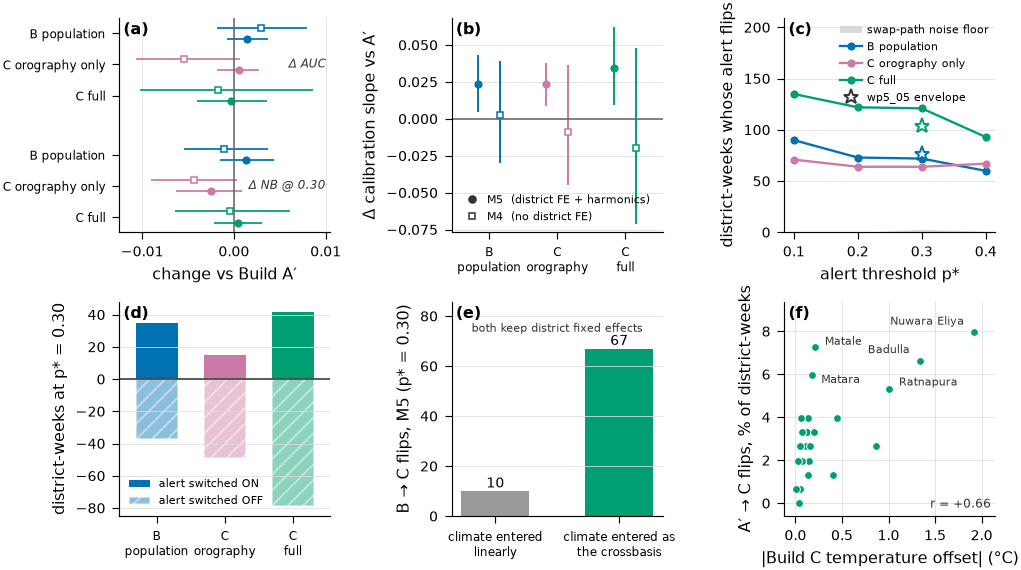

In [24]:
fig, AX = plt.subplots(2, 3, figsize=(W_DOUBLE, W_DOUBLE * 0.56))
(a, b, c), (d, e, g) = AX

# (a) dAUC and dNB vs A' ------------------------------------------------------------------
ypos, ylab, k = [], [], 0
GRP = []
for stat in ["dAUC", "dNB@0.30"]:
    GRP.append((k + 1, stat.replace("dAUC", "Δ AUC").replace("dNB@0.30", "Δ NB @ 0.30")))
    for arm in ARM3:
        for model in ["M5", "M4"]:
            r = BOOT[(BOOT.model == model) & (BOOT.arm == arm) & (BOOT.stat == stat)].iloc[0]
            yy = k + (0.18 if model == "M5" else -0.18)
            a.plot([r.lo, r.hi], [yy, yy], color=CLR[arm], lw=1.0, alpha=.9, solid_capstyle="butt")
            a.plot(r.point, yy, MK[model], color=CLR[arm], ms=3.4,
                   mfc=CLR[arm] if model == "M5" else "white", mew=.8)
        ypos.append(k); ylab.append(LBL[arm]); k += 1
    k += 0.9
a.axvline(0, color="#666666", lw=0.8)
a.set_yticks(ypos); a.set_yticklabels(ylab, fontsize=6)
a.set_xlabel("change vs Build A′"); a.invert_yaxis()
a.set_xlim(-0.0125, 0.0105); a.set_xticks([-0.01, 0, 0.01])
a.grid(axis="x", color="#dddddd")
for yy, lab in GRP:
    a.text(0.0100, yy, lab, ha="right", va="center", fontsize=6, color="#333333", style="italic")
a.text(.02, .98, "(a)", transform=a.transAxes, va="top", fontsize=8, fontweight="bold")

# (b) calibration slope -------------------------------------------------------------------
for j, arm in enumerate(ARM3):
    for model, dx in [("M5", -0.16), ("M4", 0.16)]:
        r = BOOT[(BOOT.model == model) & (BOOT.arm == arm) & (BOOT.stat == "dCalSlope")].iloc[0]
        b.plot([j + dx, j + dx], [r.lo, r.hi], color=CLR[arm], lw=1.0)
        b.plot(j + dx, r.point, MK[model], color=CLR[arm], ms=3.4,
               mfc=CLR[arm] if model == "M5" else "white", mew=.8)
b.axhline(0, color="#666666", lw=0.8)
b.plot([], [], "o", color="#333333", ms=3.4, label="M5  (district FE + harmonics)")
b.plot([], [], "s", color="#333333", ms=3.4, mfc="white", mew=.8, label="M4  (no district FE)")
b.legend(frameon=False, fontsize=5.5, loc="lower left", handletextpad=.4)
b.set_xticks(range(3)); b.set_xticklabels([SHORT[x] for x in ARM3], fontsize=6)
b.set_xlim(-0.55, 2.55)
b.set_ylabel("Δ calibration slope vs A′"); b.grid(axis="y", color="#dddddd")
b.text(.02, .98, "(b)", transform=b.transAxes, va="top", fontsize=8, fontweight="bold")

# (c) flips across the threshold band, with the noise floor and wp5_05's envelope ----------
c.fill_between(P_BAND, 0, [FLOOR[p] for p in P_BAND], color="#cccccc", alpha=.7, lw=0,
               label="swap-path noise floor")
for arm in ARM3:
    s = FLIP[(FLIP.model == "M5") & (FLIP.arm == arm)].sort_values("p_star")
    c.plot(s.p_star, s.flips, "-o", color=CLR[arm], ms=3.2, label=LBL[arm])
for rung, arm in [("A'->B", "B_pop"), ("A'->C", "C_pop")]:
    c.plot(PSTAR, int(env.loc[rung].flips_raw), "*", ms=8, mfc="white", mec=CLR[arm], mew=1.0)
c.plot([], [], "*", ms=8, mfc="white", mec="#333333", mew=1.0, label="wp5_05 envelope")
c.set_xlabel("alert threshold p*"); c.set_ylabel("district-weeks whose alert flips")
c.set_xticks(P_BAND); c.grid(axis="y", color="#dddddd")
c.set_ylim(0, FLIP[FLIP.model == "M5"].flips.max() * 1.55)
c.legend(frameon=False, fontsize=5.5, loc="upper right", handletextpad=.5, borderaxespad=.2)
c.text(.02, .98, "(c)", transform=c.transAxes, va="top", fontsize=8, fontweight="bold")

# (d) direction of the flips at p* ---------------------------------------------------------
for j, arm in enumerate(ARM3):
    r = FLIP[(FLIP.model == "M5") & (FLIP.arm == arm) & (FLIP.p_star == PSTAR)].iloc[0]
    d.bar(j, r.off_to_on, color=CLR[arm], width=.62, label="alert switched ON" if j == 0 else None)
    d.bar(j, -r.on_to_off, color=CLR[arm], width=.62, alpha=.45, hatch="///", edgecolor="white",
          label="alert switched OFF" if j == 0 else None)
d.axhline(0, color="#333333", lw=0.8)
d.set_xticks(range(3)); d.set_xticklabels([SHORT[x] for x in ARM3], fontsize=6)
d.set_xlim(-0.55, 2.55)
d.set_ylabel("district-weeks at p* = %.2f" % PSTAR); d.grid(axis="y", color="#dddddd")
d.legend(frameon=False, fontsize=5.5, loc="lower left")
d.text(.02, .98, "(d)", transform=d.transAxes, va="top", fontsize=8, fontweight="bold")

# (e) the mechanism ------------------------------------------------------------------------
e.bar([0, 1], [fl_lin, fl_cb], color=["#999999", CLR["C_pop"]], width=.55)
for x, v in [(0, fl_lin), (1, fl_cb)]:
    e.text(x, v + 1.5, "%d" % v, ha="center", fontsize=7)
e.set_xticks([0, 1]); e.set_xticklabels(["climate entered\nlinearly", "climate entered as\nthe crossbasis"], fontsize=6)
e.set_ylabel("B → C flips, M5 (p* = %.2f)" % PSTAR); e.set_ylim(0, fl_cb * 1.28)
e.grid(axis="y", color="#dddddd")
e.text(.02, .98, "(e)", transform=e.transAxes, va="top", fontsize=8, fontweight="bold")
e.text(.5, .86, "both keep district fixed effects", transform=e.transAxes, ha="center", fontsize=5.5, color="#333333")

# (f) where the flips land -----------------------------------------------------------------
g.scatter(PDIS.dT_c_pop.abs(), PDIS.flip_pct_C, s=16, color=CLR["C_pop"], edgecolor="white", linewidth=.5, zorder=3)
NUDGE = {"Nuwara Eliya": (-5, 4, "right"), "Badulla": (-5, 4, "right"),
         "Matale": (5, 1, "left"), "Matara": (5, -4, "left"), "Ratnapura": (5, 2, "left")}
for _, r in PDIS.nlargest(5, "flips_C").iterrows():
    dx, dy, ha = NUDGE.get(r.rdhs_name, (4, 2, "left"))
    g.annotate(r.rdhs_name, (abs(r.dT_c_pop), r.flip_pct_C), textcoords="offset points",
               xytext=(dx, dy), ha=ha, fontsize=5.5, color="#333333")
g.set_xlim(-0.12, PDIS.dT_c_pop.abs().max() * 1.12)
g.set_ylim(-0.6, PDIS.flip_pct_C.max() * 1.18)
g.set_xlabel("|Build C temperature offset| (°C)"); g.set_ylabel("A′ → C flips, % of district-weeks")
g.grid(color="#dddddd")
g.text(.02, .98, "(f)", transform=g.transAxes, va="top", fontsize=8, fontweight="bold")
g.text(.98, .04, "r = %+.2f" % r_off, transform=g.transAxes, ha="right", fontsize=6, color="#333333")

fig.tight_layout(pad=0.5, w_pad=1.4, h_pad=1.2)
plt.show()

In [25]:
written = []
for ext in ("pdf", "png"):
    p = FIGS / ("WP5_F7b_decision_sensitivity_refit.%s" % ext)
    fig.savefig(p, dpi=600 if ext == "png" else None)
    written.append(p)
    print("%-62s %8.1f kB" % (p.relative_to(REPO), p.stat().st_size / 1e3))

Manuscript_Figures/wp5/WP5_F7b_decision_sensitivity_refit.pdf      41.5 kB


Manuscript_Figures/wp5/WP5_F7b_decision_sensitivity_refit.png     561.0 kB


---
## 14 · Tables

Everything a downstream section might quote, plus the full prediction panel so no number here has
to be re-derived by hand.

In [26]:
OUT = W5
MET.to_csv(OUT / "wp5_05b_refit_metrics_srilanka_v1.csv", index=False)
NBB.to_csv(OUT / "wp5_05b_refit_netbenefit_band_srilanka_v1.csv", index=False)
BOOT.to_csv(OUT / "wp5_05b_refit_deltas_bootstrap_srilanka_v1.csv", index=False)
FLIP.to_csv(OUT / "wp5_05b_refit_flips_srilanka_v1.csv", index=False)
CMP.to_csv(OUT / "wp5_05b_envelope_vs_refit_srilanka_v1.csv", index=False)
KNOT.to_csv(OUT / "wp5_05b_knot_sensitivity_srilanka_v1.csv", index=False)
INC.to_csv(OUT / "wp5_05b_climate_increment_by_build_srilanka_v1.csv", index=False)
PDIS.to_csv(OUT / "wp5_05b_per_district_flips_srilanka_v1.csv", index=False)

DET = f.loc[TEST, ["geometry_id", "rdhs_name", "week_start"]].copy()
DET["y"] = YTE
for arm in ARMS:
    for kind in ["M5", "M4", "matched"]:
        DET["p_%s_%s" % (arm, kind)] = P[(arm, kind)]
DET.to_csv(OUT / "wp5_05b_refit_predictions_srilanka_v1.csv", index=False)

for p in sorted(OUT.glob("wp5_05b_*")):
    print("%-64s %8.1f kB" % (p.relative_to(REPO), p.stat().st_size / 1e3))

data_quarantine/wp5_exposure/wp5_05b_climate_increment_by_build_srilanka_v1.csv      0.4 kB
data_quarantine/wp5_exposure/wp5_05b_envelope_vs_refit_srilanka_v1.csv      0.3 kB
data_quarantine/wp5_exposure/wp5_05b_knot_sensitivity_srilanka_v1.csv      0.2 kB
data_quarantine/wp5_exposure/wp5_05b_per_district_flips_srilanka_v1.csv      2.7 kB
data_quarantine/wp5_exposure/wp5_05b_provenance.json                  5.6 kB
data_quarantine/wp5_exposure/wp5_05b_refit_deltas_bootstrap_srilanka_v1.csv      2.0 kB
data_quarantine/wp5_exposure/wp5_05b_refit_flips_srilanka_v1.csv      1.1 kB
data_quarantine/wp5_exposure/wp5_05b_refit_metrics_srilanka_v1.csv      1.5 kB
data_quarantine/wp5_exposure/wp5_05b_refit_netbenefit_band_srilanka_v1.csv      1.2 kB
data_quarantine/wp5_exposure/wp5_05b_refit_predictions_srilanka_v1.csv   1031.3 kB


---
## 15 · QC

In [27]:
checks = {}
checks["Build A' agrees across two independent builds (<1e-3)"] = (max(AGREE.values()) < 1e-3)
checks["the swap only touches already-excluded rows"]           = bool(int(chk.loc[unjoined, "exposure_missing_flag"].sum()) == int(unjoined.sum()))
checks["panel identical under all four arms"]                   = all(same.values())
checks["test panel is 3,926 rows"]                              = (int(TEST.sum()) == 3926)
checks["all 26 districts present"]                              = (len(UNITS) == 26)
checks["baseline reproduces sl_04 M5 exactly"]                  = (g_M5 == 0.0)
checks["baseline reproduces sl_04 M5_noclim exactly"]           = (g_nc == 0.0)
checks["no-climate twin is invariant across arms (exactly)"]    = (NC_MAX == 0.0)
checks["swap-path noise floor < 5 flips at every p*"]           = all(v < 5 for v in FLOOR.values())
checks["every flip count exceeds 10x the noise floor"]          = bool((FLIP[FLIP.p_star == PSTAR].flips > 10 * max(FLOOR[PSTAR], 1)).all())
checks["every prediction in (0,1)"]                             = bool(all(((v > 0) & (v < 1)).all() for v in P.values()))
checks["metrics cover 4 arms x 3 models"]                       = (len(MET) == 12)
checks["bootstrap covers 2 models x 3 arms x 3 stats"]          = (len(BOOT) == 18)
checks["flip table covers 2 models x 3 arms x 4 thresholds"]    = (len(FLIP) == 24)
checks["refit flip rate stays under wp5_05's 6.0% bound"]       = bool(FLIP.flip_pct.max() < 6.0)
checks["linear-exposure M5 absorbs B->C (fewer than a fifth)"]  = (fl_lin < fl_cb / 5)
checks["increment table covers every arm"]                      = (len(INC) == 4)
checks["per-district table covers 26 districts"]                = (len(PDIS) == 26)
checks["figure written as pdf and png"]                         = (len(written) == 2 and all(p.exists() for p in written))
checks["C never left the grid in the baseline"]                 = (C_lk in CGRID)

for k, v in checks.items():
    print("%-56s %s" % (k, "PASS" if v else "FAIL"))
n_pass = sum(bool(v) for v in checks.values())
print("\n%d/%d" % (n_pass, len(checks)))
assert n_pass == len(checks), "QC failed"


Build A' agrees across two independent builds (<1e-3)    PASS
the swap only touches already-excluded rows              PASS
panel identical under all four arms                      PASS
test panel is 3,926 rows                                 PASS
all 26 districts present                                 PASS
baseline reproduces sl_04 M5 exactly                     PASS
baseline reproduces sl_04 M5_noclim exactly              PASS
no-climate twin is invariant across arms (exactly)       PASS
swap-path noise floor < 5 flips at every p*              PASS
every flip count exceeds 10x the noise floor             PASS
every prediction in (0,1)                                PASS
metrics cover 4 arms x 3 models                          PASS
bootstrap covers 2 models x 3 arms x 3 stats             PASS
flip table covers 2 models x 3 arms x 4 thresholds       PASS
refit flip rate stays under wp5_05's 6.0% bound          PASS
linear-exposure M5 absorbs B->C (fewer than a fifth)     PASS
incremen

In [28]:
prov = {
    "notebook": "wp5_05b_decision_sensitivity_refit",
    "workpackage": "WP5",
    "country": "sri_lanka",
    "plan_section": "3.3 (decision-sensitivity re-run) - the half wp5_05 could not run",
    "registered_rerun": False,
    "rerun_status": ("independent-rebuild version. The frozen linked table is not on this machine; "
                     "M5/M4 are refitted on the sl_ladder rebuild (ERA5 0.25 deg + CHIRPS). Must NOT "
                     "be reported as the registered re-run."),
    "supersedes_claim": ("wp5_05's blocker note said the design matrices are absent. "
                         "sl_matched_and_recal.py carries them; the missing piece was the input "
                         "table, and sl_linked_v2equiv.csv substitutes for it with measured fidelity."),
    "environment": {"kernel": "python3", "venv": "/Users/mpcr/aj/Dengue/.venv",
                    "python": "3.14.7", "sklearn": "1.9.0",
                    "reason": "the only env here that reproduces sl_04 exactly"},
    "seed": SEED,
    "inputs": {"linked_table": "data_quarantine/sl_ladder/sl_linked_v2equiv.csv",
               "temp_twin": "data_quarantine/wp5_exposure/wp5_temp_exposure_twin_srilanka_v1.csv",
               "precip_twin": "data_quarantine/wp5_exposure/wp5_precip_exposure_twin_srilanka_v1.csv",
               "build_c": "data_quarantine/wp5_exposure/wp5_buildC_temp_exposure_srilanka_v1.csv",
               "gate": "data_quarantine/sl_ladder/sl_predictions.npz",
               "envelope": "data_quarantine/wp5_exposure/wp5_decision_flip_summary_srilanka_v1.csv"},
    "gates": {"buildA_agreement_max_abs": AGREE,
              "baseline_vs_sl04_M5_max_abs": g_M5,
              "baseline_vs_sl04_noclim_max_abs": g_nc,
              "noclimate_invariance_max_abs": NC_MAX,
              "swap_path_noise_floor_max_dp": FLOOR_DP,
              "swap_path_noise_floor_flips": {str(k): v for k, v in FLOOR.items()}},
    "design": {"arms": {k: {"t2m_rh": v[0], "precip": v[1]} for k, v in ARMS.items()},
               "models": ["M5", "M4 (no district FE, no harmonics)", "M5 no-climate twin"],
               "thresholds": P_BAND, "headline_threshold": PSTAR,
               "bootstrap": {"B": N_BOOT, "unit": "RDHS district", "paired": True},
               "knots": "re-derived per arm from that arm's training rows; fixed-knot variant in section 9.1"},
    "results": {
        "auc": {a: float(MET[(MET.arm == a) & (MET.model == "M5")].AUC.iloc[0]) for a in ARMS},
        "nb30": {a: float(MET[(MET.arm == a) & (MET.model == "M5")]["NB@0.30"].iloc[0]) for a in ARMS},
        "cal_slope": {a: float(MET[(MET.arm == a) & (MET.model == "M5")].cal_slope.iloc[0]) for a in ARMS},
        "flips_at_pstar_M5": {a: int(FLIP[(FLIP.model == "M5") & (FLIP.arm == a) & (FLIP.p_star == PSTAR)].flips.iloc[0]) for a in ARM3},
        "deltas_excluding_zero": [f"{r.model} {r.arm} {r.stat}" for r in BOOT.itertuples() if r.excludes_0],
        "envelope_vs_refit": CMP.to_dict("records"),
        "mechanism": {"B_to_C_flips_linear_exposure": fl_lin, "B_to_C_flips_crossbasis": fl_cb},
        "increment_dNB_by_build": {r.arm: float(r.dNB_increment) for r in INC.itertuples()}},
    "corrects": ("decision log 2026-08-13: 'district-relative models absorb Build C exactly -> Build C "
                 "cannot flip any alert'. True for models LINEAR in temperature (%d flips); false for "
                 "M5, whose crossbasis is nonlinear (%d flips)." % (fl_lin, fl_cb)),
    "qc": {"checks": len(checks), "passed": n_pass},
    "figure": [str(p.relative_to(REPO)) for p in written],
    "tables": [str(p.relative_to(REPO)) for p in sorted(OUT.glob("wp5_05b_*.csv"))],
}
(OUT / "wp5_05b_provenance.json").write_text(json.dumps(prov, indent=2, default=float))
print(json.dumps(prov["results"], indent=2, default=float)[:1800])
print("\nwrote", (OUT / "wp5_05b_provenance.json").relative_to(REPO))

{
  "auc": {
    "A_frac": 0.7653158969047746,
    "B_pop": 0.7667887355996201,
    "C_frac": 0.7658566731145691,
    "C_pop": 0.7649823747013104
  },
  "nb30": {
    "A_frac": 0.13859981078524125,
    "B_pop": 0.1399097591150571,
    "C_frac": 0.13612546394003347,
    "C_pop": 0.13900007277490722
  },
  "cal_slope": {
    "A_frac": 1.0847205650455163,
    "B_pop": 1.108094127976112,
    "C_frac": 1.1082638725794483,
    "C_pop": 1.1192395776842166
  },
  "flips_at_pstar_M5": {
    "B_pop": 72,
    "C_frac": 64,
    "C_pop": 121
  },
  "deltas_excluding_zero": [
    "M5 B_pop dCalSlope",
    "M5 C_frac dCalSlope",
    "M5 C_pop dCalSlope"
  ],
  "envelope_vs_refit": [
    {
      "rung": "A'->B",
      "envelope_flips": 76,
      "envelope_pct": 1.9358125318390216,
      "refit_flips": 72,
      "refit_pct": 1.8339276617422313,
      "refit_minus_envelope": -4,
      "envelope_dNB": -0.0012371734226038,
      "refit_dNB": 0.0013099483298158465
    },
    {
      "rung": "A'->C",
      

---
## 16 · Recap

| question | statistic | answer |
|---|---|---|
| Does exposure construction change **discrimination**? | ΔAUC vs A′ | No — every interval spans zero, range across builds < 0.002 |
| Does it change **net benefit**? | ΔNB@0.30 | No — every interval spans zero, abs(Δ) ≤ 0.003 |
| Does it change **calibration**? | Δ slope | **Yes for M5** — small (+0.02 to +0.035) but every interval excludes zero, and away from 1 |
| Does it change **the decision**? | alerts flipped | **Yes** — 72 (B), 64 (orography), 121 (both), against a 3-flip noise floor |
| Was `wp5_05`'s envelope any good? | envelope vs refit | Held at both rungs; under-counted A′→C, the direction it predicted |
| Is it the knots? | fixed-knot refit | No — flips survive |
| Why does Build C move a model with district FE? | linear vs crossbasis | The **nonlinear** exposure–response; linearise it and the flips collapse |
| Where? | per-district | The highlands, where the offset is largest, and predominantly *off* |
| Is the climate block worth less under another build? | Δ increment | No — every change-vs-A′ interval spans zero |

**The one-line result.** Exposure construction does not move what the model *scores*; it moves what
the model *decides*, for a few per cent of district-weeks, concentrated where the terrain
correction is largest. A sensitivity analysis that reads only ΔAUC and ΔNB would have reported a
null.